# 06 · Evaluation — hasil pengujian, interpretasi (SHAP), & cek kriteria sukses
Fase CRISP-DM 5: **Evaluate results → Review process → Determine next steps**.

Semua angka di notebook ini berasal dari prediksi **out-of-sample** walk-forward (Jan 2022 – terbaru): model tidak pernah melihat data periode uji saat dilatih.

In [1]:
# --- Setup: path project, modul radarpangan, gaya grafik -----------------------------------
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", message="IProgress not found")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from radarpangan.config import load_project
cfg, P = load_project(ROOT)
pd.set_option("display.max_columns", 60); pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("Project:", ROOT)

Project: /home/claude/MiningProcess


In [2]:
from radarpangan.pipeline import load_refs, feature_columns, lgbm_params
from radarpangan.evaluation import compare_models, pr_auc_by, site_summary, MODEL_LABELS
from radarpangan.metrics import pr_auc, event_detection, alarm_episodes, at_threshold
from radarpangan.validation import make_folds, modeling_frame
from radarpangan.viz import MODEL_COLORS, PALETTE, plot_network_map
from radarpangan.geo import load_geojson
from radarpangan.reference import province_reference
from sklearn.metrics import precision_recall_curve

refs = load_refs(P)
H = cfg["target"]["horizon_days"]
events = pd.read_parquet(P.processed / "events.parquet")
pred = pd.read_parquet(P.processed / "oof_predictions.parquet")
pred["kategori"] = pred["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])
events["kategori"] = events["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])
models = ["naive", "seasonal", "logreg", "lgbm"]
print(f"Prediksi uji: {len(pred):,} baris | {pred['date'].min():%d %b %Y} – {pred['date'].max():%d %b %Y} | "
      f"proporsi positif {pred['y'].mean():.2%} | kejadian di periode uji: {((events['date'] >= pred['date'].min()) & (events['date'] <= pred['date'].max())).sum():,}")

Prediksi uji: 805,533 baris | 03 Jan 2022 – 11 Sep 2026 | proporsi positif 5.38% | kejadian di periode uji: 4,340


## 6.1 Perbandingan model (seluruh periode uji)
- **PR-AUC**: kualitas peringkat risiko tanpa ambang (acak = proporsi positif).
- **Presisi / Recall / FAR** pada ambang alarm yang dipilih di data validasi tiap fold.
- **Deteksi kejadian**: % onset lonjakan yang didahului ≥ 1 alarm dalam 14 hari sebelumnya; **lead time** = jarak alarm pertama ke onset.
- **Episode alarm palsu**: rangkaian alarm yang tidak diikuti lonjakan, per seri (provinsi × varian) per tahun.

In [3]:
table = compare_models(pred, events, H, models)
nice = table.rename(columns={"model": "Model", "pr_auc": "PR-AUC", "roc_auc": "ROC-AUC", "precision": "Presisi", "recall": "Recall",
                             "f1": "F1", "far": "FAR", "event_detection_rate": "Deteksi kejadian", "median_lead_days": "Median lead (hari)",
                             "share_lead_ge_7": "Kejadian dg lead ≥7 hr", "false_episodes_per_series_year": "Episode alarm palsu/seri/thn"})
cols = ["Model", "PR-AUC", "ROC-AUC", "Presisi", "Recall", "F1", "FAR", "Deteksi kejadian", "Median lead (hari)", "Kejadian dg lead ≥7 hr", "Episode alarm palsu/seri/thn"]
display(nice[cols].style.format({c: "{:.3f}" for c in cols[1:]}).format({"Median lead (hari)": "{:.0f}"}).hide(axis="index")
        .highlight_max(subset=["PR-AUC", "ROC-AUC", "F1", "Deteksi kejadian"], color="#d3f0e4"))
table.to_csv(P.tables / "06_perbandingan_model.csv", index=False)
summary = site_summary(table)
(P.tables / "eval_summary.json").write_text(json.dumps(summary, indent=1))
base = pred["y"].mean()
lg, nv = table.set_index("key").loc["lgbm"], table.set_index("key").loc["naive"]
print(f"LightGBM PR-AUC {lg['pr_auc']:.3f} = {lg['pr_auc'] / nv['pr_auc']:.2f}x baseline 'harga minggu lalu' ({nv['pr_auc']:.3f}) "
      f"dan {lg['pr_auc'] / base:.1f}x tebakan acak ({base:.3f})")

Model,PR-AUC,ROC-AUC,Presisi,Recall,F1,FAR,Deteksi kejadian,Median lead (hari),Kejadian dg lead ≥7 hr,Episode alarm palsu/seri/thn
"Naive ""harga minggu lalu""",0.256008,0.615445,0.308107,0.352413,0.328774,0.691893,0.850684,7,0.499188,2.682731
Seasonal naive (tahun lalu),0.113625,0.506968,0.176319,0.277303,0.215571,0.823681,0.495942,13,0.383492,2.000510
Regresi logistik,0.397675,0.878389,0.376736,0.516671,0.435744,0.623264,0.788546,11,0.648968,1.642588
LightGBM,0.501147,0.919809,0.451951,0.540129,0.492122,0.548049,0.846511,11,0.668908,1.303923


LightGBM PR-AUC 0.501 = 1.96x baseline 'harga minggu lalu' (0.256) dan 9.3x tebakan acak (0.054)


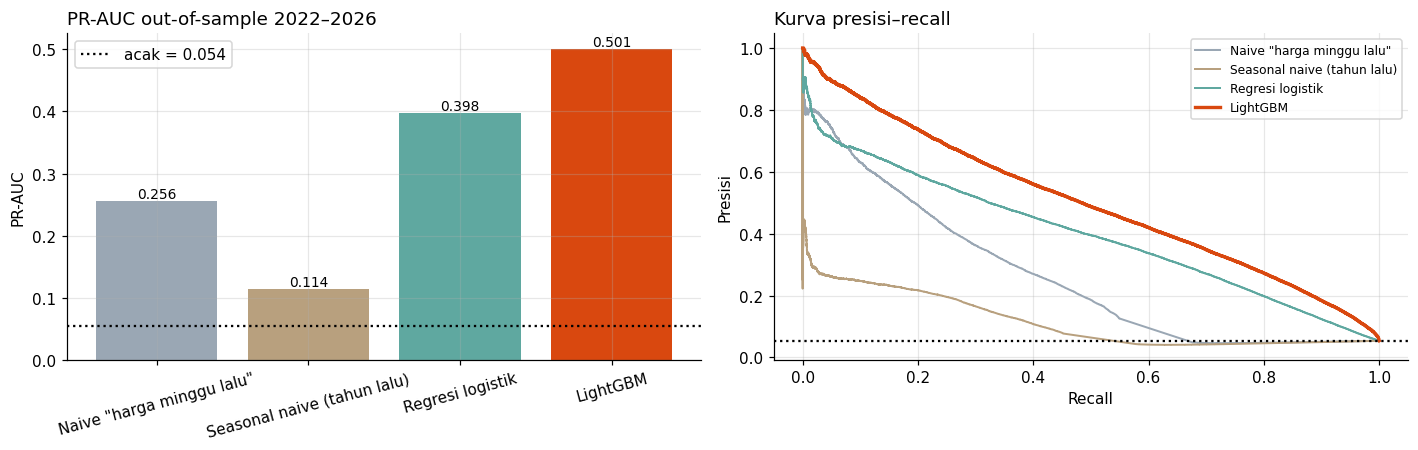

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.2))
t = table.set_index("key")
ax1.bar([MODEL_LABELS[m] for m in models], t.loc[models, "pr_auc"], color=[MODEL_COLORS[m] for m in models])
ax1.axhline(base, ls=":", color="k", label=f"acak = {base:.3f}")
for i, m in enumerate(models):
    ax1.text(i, t.at[m, "pr_auc"] + 0.005, f"{t.at[m, 'pr_auc']:.3f}", ha="center", fontsize=9)
ax1.set_ylabel("PR-AUC"); ax1.tick_params(axis="x", rotation=15); ax1.legend(); ax1.set_title("PR-AUC out-of-sample 2022–2026", loc="left")
for m in models:
    s = pred[f"score_{m}"].to_numpy(); ok = np.isfinite(s)
    pr_, rc_, _ = precision_recall_curve(pred["y"].to_numpy()[ok], s[ok])
    ax2.plot(rc_, pr_, label=MODEL_LABELS[m], color=MODEL_COLORS[m], lw=2.2 if m == "lgbm" else 1.3)
ax2.axhline(base, ls=":", color="k"); ax2.set_xlabel("Recall"); ax2.set_ylabel("Presisi"); ax2.legend(fontsize=8)
ax2.set_title("Kurva presisi–recall", loc="left")
fig.tight_layout(); fig.savefig(P.figures / "fig_06_01_perbandingan_model.png", dpi=170, bbox_inches="tight"); plt.show()

## 6.2 Per kategori komoditas

In [5]:
cat_tab = pr_auc_by(pred, "kategori", models).set_index("kategori").sort_values("lgbm", ascending=False)
cat_tab["lgbm / naive"] = cat_tab["lgbm"] / cat_tab["naive"]
ed = event_detection(pred, events, H, "score_lgbm", "thr_lgbm")
ed["kategori"] = ed["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])
cat_tab = cat_tab.join(ed.groupby("kategori").agg(kejadian=("detected", "size"), deteksi=("detected", "mean"),
                                                  median_lead=("lead_days", "median")))
display(cat_tab.style.format({"pos_rate": "{:.2%}", "naive": "{:.3f}", "seasonal": "{:.3f}", "logreg": "{:.3f}", "lgbm": "{:.3f}",
                              "lgbm / naive": "{:.2f}x", "deteksi": "{:.0%}", "median_lead": "{:.0f}", "n": "{:,}", "kejadian": "{:,}"}))
cat_tab.to_csv(P.tables / "06_per_kategori.csv")
win = cat_tab[cat_tab["lgbm"] > cat_tab["naive"]].index.tolist(); lose = cat_tab[cat_tab["lgbm"] <= cat_tab["naive"]].index.tolist()
print(f"LightGBM > naive di {len(win)} dari {len(cat_tab)} kategori.")
if lose:
    rates = ", ".join("{:.1%}".format(cat_tab.at[k, "pos_rate"]) for k in lose)
    print("Kategori di mana naive setara/lebih baik: " + ", ".join(lose) + " (proporsi positif " + rates + ")"
          " -> kejadian sangat jarang; sinyal sederhana 'harga minggu lalu' sudah menangkap sebagian besar informasi.")

,n,pos_rate,naive,seasonal,logreg,lgbm,lgbm / naive,kejadian,deteksi,median_lead
kategori,,,,,,,,,,
Cabai Merah,"60,395",25.56%,0.427,0.252,0.489,0.600,1.41x,"1,538",98%,13
Cabai Rawit,"62,642",20.93%,0.403,0.245,0.493,0.587,1.46x,"1,306",97%,11
Bawang Merah,"37,887",11.25%,0.357,0.138,0.403,0.496,1.39x,425,96%,8
Daging Ayam,"41,011",3.48%,0.204,0.072,0.238,0.348,1.71x,142,89%,7
Beras,"239,528",1.87%,0.145,0.029,0.064,0.212,1.46x,448,25%,6
Bawang Putih,"41,244",1.75%,0.138,0.021,0.135,0.206,1.49x,72,75%,5
Daging Sapi,"80,329",1.13%,0.076,0.052,0.075,0.184,2.42x,90,47%,9
Minyak Goreng,"119,353",1.69%,0.106,0.020,0.133,0.163,1.54x,203,41%,4
Gula Pasir,"81,716",0.76%,0.113,0.007,0.045,0.092,0.81x,59,44%,5


LightGBM > naive di 8 dari 10 kategori.
Kategori di mana naive setara/lebih baik: Gula Pasir, Telur Ayam (proporsi positif 0.8%, 0.7%) -> kejadian sangat jarang; sinyal sederhana 'harga minggu lalu' sudah menangkap sebagian besar informasi.


## 6.3 Evaluasi berbasis kejadian: deteksi, lead time, alarm palsu

Kejadian lonjakan di periode uji (jendela peringatan lengkap): 4,313
Terdeteksi (didahului alarm): 84.7% | median lead time: 11 hari | rata-rata: 9.9 hari | lead >= 7 hari: 66.9% dari semua kejadian


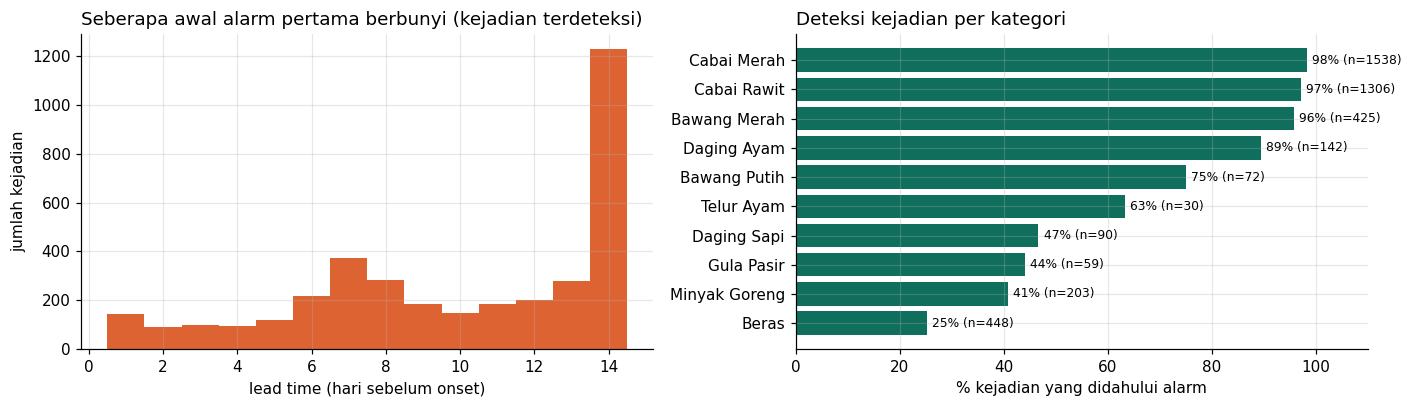

Episode alarm: 8,220 | benar (diikuti lonjakan): 48.1% | median durasi episode: 4 hari kerja


In [6]:
print(f"Kejadian lonjakan di periode uji (jendela peringatan lengkap): {len(ed):,}")
print(f"Terdeteksi (didahului alarm): {ed['detected'].mean():.1%} | median lead time: {ed['lead_days'].median():.0f} hari | "
      f"rata-rata: {ed['lead_days'].mean():.1f} hari | lead >= 7 hari: {(ed['lead_days'] >= 7).mean():.1%} dari semua kejadian")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.8))
ax1.hist(ed.loc[ed["detected"], "lead_days"], bins=np.arange(0.5, 15.5, 1), color=PALETTE["high"], alpha=.85)
ax1.set_xlabel("lead time (hari sebelum onset)"); ax1.set_ylabel("jumlah kejadian")
ax1.set_title("Seberapa awal alarm pertama berbunyi (kejadian terdeteksi)", loc="left")
dk = ed.groupby("kategori").agg(deteksi=("detected", "mean"), n=("detected", "size")).sort_values("deteksi")
ax2.barh(dk.index, dk["deteksi"] * 100, color=PALETTE["accent"])
for i, (v, n) in enumerate(zip(dk["deteksi"], dk["n"])):
    ax2.text(v * 100 + 1, i, f"{v:.0%} (n={n})", va="center", fontsize=8)
ax2.set_xlim(0, 110); ax2.set_xlabel("% kejadian yang didahului alarm"); ax2.set_title("Deteksi kejadian per kategori", loc="left")
fig.tight_layout(); fig.savefig(P.figures / "fig_06_02_lead_time.png", dpi=170, bbox_inches="tight"); plt.show()
ep = alarm_episodes(pred, events, H, "score_lgbm", "thr_lgbm")
print(f"Episode alarm: {len(ep):,} | benar (diikuti lonjakan): {1 - ep['is_false'].mean():.1%} | median durasi episode: {ep['n_days'].median():.0f} hari kerja")

### Trade-off ambang alarm
Ambang menentukan keseimbangan "alarm cukup awal & banyak kejadian tertangkap" vs "alarm palsu". Kurva di bawah membantu pengguna (mis. TPID) memilih titik operasi.

ambang,presisi,FAR,deteksi kejadian,median lead,episode palsu/seri/thn,porsi hari beralarm
0.05,22.9%,77.1%,95.7%,14,2.73,20.0%
0.10,30.7%,69.3%,92.5%,14,2.12,13.3%
0.15,36.5%,63.5%,89.4%,14,1.77,10.0%
0.20,41.2%,58.8%,86.9%,13,1.52,7.9%
0.25,45.7%,54.3%,84.5%,11,1.31,6.4%
0.30,49.8%,50.2%,81.8%,10,1.11,5.3%
0.40,57.7%,42.3%,75.9%,8,0.79,3.5%
0.50,65.8%,34.2%,67.8%,7,0.53,2.3%
0.60,74.3%,25.7%,57.5%,6,0.31,1.4%


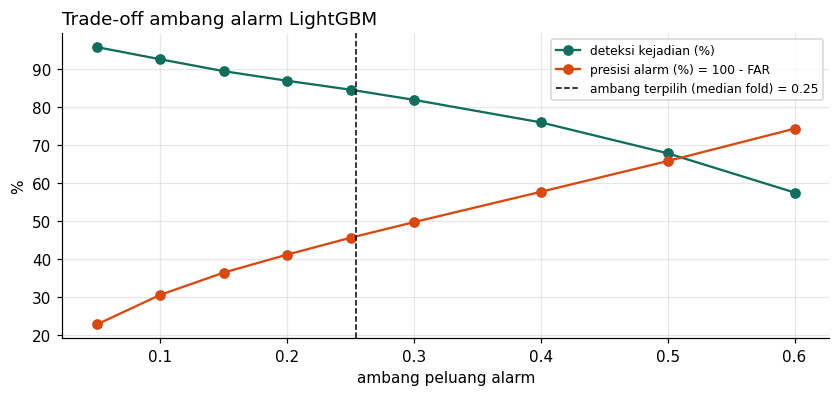

In [7]:
grid = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]
rows = []
for g in grid:
    tmp = pred[["date", "commodity_id", "province_id", "y", "score_lgbm"]].copy(); tmp["thr"] = g
    e_ = event_detection(tmp, events, H, "score_lgbm", "thr")
    a_ = at_threshold(tmp["y"], tmp["score_lgbm"], g)
    ep_ = alarm_episodes(tmp, events, H, "score_lgbm", "thr")
    yrs = (tmp["date"].max() - tmp["date"].min()).days / 365.25
    rows.append({"ambang": g, "presisi": a_["precision"], "FAR": a_["far"], "deteksi kejadian": e_["detected"].mean(),
                 "median lead": e_["lead_days"].median(), "episode palsu/seri/thn": ep_["is_false"].sum() / (tmp.groupby(["commodity_id", "province_id"]).ngroups * yrs),
                 "porsi hari beralarm": a_["alarm_rate"]})
to = pd.DataFrame(rows)
display(to.style.format({"ambang": "{:.2f}", "presisi": "{:.1%}", "FAR": "{:.1%}", "deteksi kejadian": "{:.1%}", "median lead": "{:.0f}",
                         "episode palsu/seri/thn": "{:.2f}", "porsi hari beralarm": "{:.1%}"}).hide(axis="index"))
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(to["ambang"], to["deteksi kejadian"] * 100, marker="o", label="deteksi kejadian (%)", color=PALETTE["accent"])
ax.plot(to["ambang"], to["presisi"] * 100, marker="o", label="presisi alarm (%) = 100 - FAR", color=PALETTE["high"])
ax.axvline(pred["thr_lgbm"].median(), ls="--", color="k", lw=1, label=f"ambang terpilih (median fold) = {pred['thr_lgbm'].median():.2f}")
ax.set_xlabel("ambang peluang alarm"); ax.set_ylabel("%"); ax.legend(fontsize=8); ax.set_title("Trade-off ambang alarm LightGBM", loc="left")
fig.savefig(P.figures / "fig_06_03_tradeoff_ambang.png", dpi=170, bbox_inches="tight"); plt.show()
to.to_csv(P.tables / "06_tradeoff_ambang.csv", index=False)

## 6.4 Pembanding SARIMA (subset komoditas volatil, origin mingguan)
Dibandingkan pada baris yang **persis sama** (setiap Jumat, 5 varian × 34 provinsi).

In [8]:
sar_path = P.processed / "oof_sarima.parquet"
if sar_path.exists():
    sar = pd.read_parquet(sar_path)
    key = ["date", "commodity_id", "province_id"]
    sub = pred.merge(sar[key + ["score_sarima", "thr_sarima"]], on=key, how="inner")
    tab_s = compare_models(sub, events, H, ["naive", "seasonal", "sarima", "logreg", "lgbm"])
    display(tab_s[["model", "pr_auc", "roc_auc", "precision", "recall", "far", "event_detection_rate", "median_lead_days", "n_rows"]]
            .style.format({"pr_auc": "{:.3f}", "roc_auc": "{:.3f}", "precision": "{:.3f}", "recall": "{:.3f}", "far": "{:.3f}",
                           "event_detection_rate": "{:.1%}", "median_lead_days": "{:.0f}", "n_rows": "{:,}"}).hide(axis="index"))
    tab_s.to_csv(P.tables / "06_perbandingan_sarima.csv", index=False)
    print(f"Varian: {[refs['com_name'][c] for c in sub['commodity_id'].unique()]}")
else:
    print("oof_sarima.parquet belum ada — jalankan bagian SARIMA di notebook 05.")

model,pr_auc,roc_auc,precision,recall,far,event_detection_rate,median_lead_days,n_rows
"Naive ""harga minggu lalu""",0.317,0.623,0.315,0.406,0.685,73.5%,5,"36,448"
Seasonal naive (tahun lalu),0.170,0.508,0.193,0.325,0.807,45.4%,11,"36,448"
SARIMA (ARIMA + Fourier),0.319,0.809,0.284,0.648,0.716,78.7%,11,"36,448"
Regresi logistik,0.466,0.851,0.385,0.640,0.615,83.7%,10,"36,448"
LightGBM,0.579,0.895,0.469,0.656,0.531,85.8%,10,"36,448"


Varian: ['Daging Ayam Ras Segar', 'Telur Ayam Ras Segar', 'Bawang Merah Ukuran Sedang', 'Cabai Merah Keriting', 'Cabai Rawit Merah']


## 6.5 Ablation: kontribusi tiap kelompok sinyal
ΔPR-AUC = PR-AUC model lengkap − PR-AUC tanpa kelompok tersebut. Positif = kelompok itu membantu. Konsistensi diperiksa per fold (berapa fold model lengkap lebih baik).

PR-AUC model lengkap: 0.5011


varian,PR-AUC,ΔPR-AUC (lengkap − varian),Δ rata2 per fold,fold lengkap lebih baik
hanya harga sendiri + identitas,0.4363,+0.0649,+0.0573,19/19
tanpa kalender,0.4715,+0.0297,+0.0229,17/19
tanpa tetangga & pemimpin (tanpa sinyal spasial),0.4767,+0.0244,+0.0195,18/19
tanpa pemimpin,0.4952,+0.0060,+0.0062,14/19
tanpa tetangga,0.4970,+0.0041,+0.0042,13/19
tanpa cuaca,0.5002,+0.0010,+0.0022,10/19
tanpa rantai_pasok,0.5045,-0.0034,-0.0025,6/19


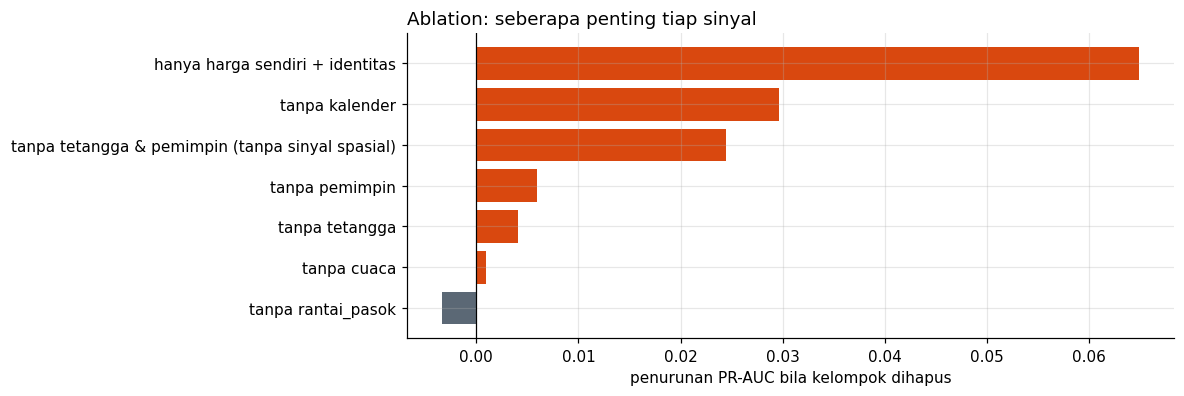

,kategori,n,pos_rate,full,norp,Δ rantai pasok
5,Daging Ayam,41011,0.0348,0.3478,0.3411,0.0067
8,Minyak Goreng,119353,0.0169,0.1627,0.1590,0.0037
2,Beras,239528,0.0187,0.2118,0.2120,-0.0003
4,Cabai Rawit,62642,0.2093,0.5874,0.5904,-0.0030
0,Bawang Merah,37887,0.1125,0.4958,0.5010,-0.0052
3,Cabai Merah,60395,0.2556,0.6000,0.6052,-0.0052
9,Telur Ayam,41428,0.0075,0.0769,0.0823,-0.0054
1,Bawang Putih,41244,0.0175,0.2055,0.2113,-0.0057
7,Gula Pasir,81716,0.0076,0.0916,0.0973,-0.0057
6,Daging Sapi,80329,0.0113,0.1844,0.1912,-0.0067


In [9]:
abl_path = P.processed / "oof_ablation.parquet"
if abl_path.exists():
    abl = pd.read_parquet(abl_path)
    variants = [c for c in abl.columns if c not in ("date", "commodity_id", "province_id", "y", "fold", "semua fitur")]
    full = pr_auc(abl["y"], abl["semua fitur"])
    per_fold_full = abl.groupby("fold").apply(lambda g: pr_auc(g["y"], g["semua fitur"]))
    rows = []
    for v in variants:
        pfv = abl.groupby("fold").apply(lambda g: pr_auc(g["y"], g[v]))
        d = per_fold_full - pfv
        rows.append({"varian": v, "PR-AUC": pr_auc(abl["y"], abl[v]), "ΔPR-AUC (lengkap − varian)": full - pr_auc(abl["y"], abl[v]),
                     "Δ rata2 per fold": d.mean(), "fold lengkap lebih baik": f"{(d > 0).sum()}/{len(d)}"})
    at = pd.DataFrame(rows).sort_values("ΔPR-AUC (lengkap − varian)", ascending=False)
    print(f"PR-AUC model lengkap: {full:.4f}")
    display(at.style.format({"PR-AUC": "{:.4f}", "ΔPR-AUC (lengkap − varian)": "{:+.4f}", "Δ rata2 per fold": "{:+.4f}"}).hide(axis="index"))
    at.to_csv(P.tables / "06_ablation.csv", index=False)
    fig, ax = plt.subplots(figsize=(9, 3.6))
    ax.barh(at["varian"], at["ΔPR-AUC (lengkap − varian)"], color=[PALETTE["high"] if x > 0 else PALETTE["muted"] for x in at["ΔPR-AUC (lengkap − varian)"]])
    ax.axvline(0, color="k", lw=.8); ax.invert_yaxis(); ax.set_xlabel("penurunan PR-AUC bila kelompok dihapus")
    ax.set_title("Ablation: seberapa penting tiap sinyal", loc="left")
    fig.savefig(P.figures / "fig_06_04_ablation.png", dpi=170, bbox_inches="tight"); plt.show()
    if "tanpa rantai_pasok" in abl.columns:
        kc = pr_auc_by(abl.assign(kategori=abl["commodity_id"].map(refs["c2cat"]).map(refs["cat_name"])).rename(
            columns={"semua fitur": "score_full", "tanpa rantai_pasok": "score_norp"}), "kategori", ["full", "norp"])
        kc["Δ rantai pasok"] = kc["full"] - kc["norp"]
        display(kc.sort_values("Δ rantai pasok", ascending=False).round(4))
else:
    print("oof_ablation.parquet belum ada — jalankan bagian ablation di notebook 05.")

**Interpretasi ablation (run ini):**
- **Kalender** adalah kelompok sinyal tunggal paling berharga: PR-AUC turun ±0,030 bila dihapus dan lebih buruk di 17/19 fold → momen Ramadan–Idulfitri–Iduladha–Nataru sangat menentukan.
- **Sinyal spasial** (tetangga + provinsi pemimpin) bersama-sama menyumbang ±0,024 (18/19 fold). Secara terpisah kontribusinya kecil karena informasinya tumpang tindih (saling menggantikan); provinsi pemimpin sedikit lebih informatif daripada tetangga geografis (14/19 vs 13/19 fold).
- **Curah hujan**: kontribusi sangat kecil dan tidak konsisten (10/19 fold).
- **Rantai pasok (margin produsen–konsumen)**: **tidak menambah** PR-AUC — model justru sedikit lebih baik tanpa fitur ini (model lengkap hanya unggul di 6/19 fold), kecuali sedikit membantu daging ayam & minyak goreng. Hipotesis awal "selisih produsen–konsumen sebagai sinyal awal" **tidak terbukti** pada data PIHPS tingkat provinsi — kemungkinan karena harga produsen tidak lengkap, jarang diperbarui, dan disurvei di lokasi berbeda dari pasar konsumen. Temuan negatif ini tetap penting dilaporkan.

## 6.6 Interpretasi model dengan SHAP
Satu model LightGBM dilatih persis seperti fold walk-forward yang dimulai ±1 tahun sebelum data terakhir, lalu dijelaskan pada prediksi **out-of-sample**-nya (±1 tahun terakhir). Nilai SHAP (TreeSHAP) menunjukkan kontribusi tiap fitur terhadap log-odds risiko.

Model SHAP: latih s.d. 02 Feb 2025, dijelaskan pada 38,235 baris uji sejak 01 Jul 2025


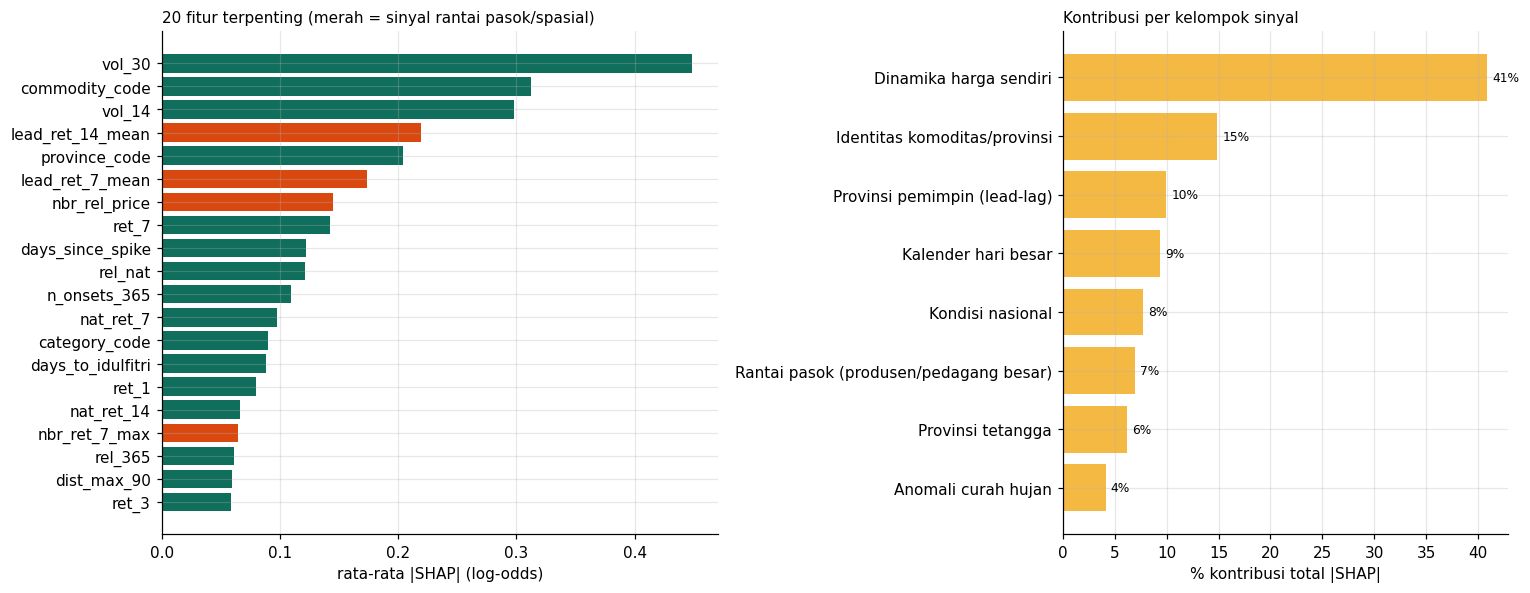

In [10]:
from radarpangan import models as M
from radarpangan.explain import lgbm_shap, importance_table, group_importance, top_reasons, GROUP_LABELS
feats = pd.read_parquet(P.processed / "features.parquet")
groups = json.loads((P.processed / "feature_groups.json").read_text(encoding="utf-8"))
data = modeling_frame(feats); del feats
fcols = feature_columns(data, groups)
folds = make_folds(data["date"], cfg)
fx = folds.iloc[max(0, len(folds) - 5)]
fit = data[data["date"] <= fx.fit_end]; val = data[(data["date"] >= fx.val_start) & (data["date"] <= fx.val_end)]
oos = data[data["date"] >= fx.test_start]
booster = M.train_lgbm(fit[fcols], fit["y"].to_numpy(), val[fcols], val["y"].to_numpy(), lgbm_params(cfg, P),
                       ["commodity_code", "category_code", "province_code"], cfg["model"]["neg_sample_rate"], cfg["project"]["random_seed"])
thr_shap = pred.loc[pred["fold"] == fx.fold, "thr_lgbm"].iloc[0] if (pred["fold"] == fx.fold).any() else 0.3
rng = np.random.default_rng(0)
idx = np.r_[np.nonzero(oos["y"].to_numpy() == 1)[0], rng.choice(len(oos), size=min(30000, len(oos)), replace=False)]
Xs = oos.iloc[np.unique(idx)][fcols]
sv, base_val = lgbm_shap(booster, Xs)
imp = importance_table(sv, fcols, groups)
gi = group_importance(imp)
print(f"Model SHAP: latih s.d. {fx.fit_end:%d %b %Y}, dijelaskan pada {len(Xs):,} baris uji sejak {fx.test_start:%d %b %Y}")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.25, 1]})
top = imp.head(20).iloc[::-1]
ax1.barh(top["feature"], top["mean_abs_shap"], color=[PALETTE["high"] if g in ("rantai_pasok", "tetangga", "pemimpin") else PALETTE["accent"] for g in top["group"]])
ax1.set_xlabel("rata-rata |SHAP| (log-odds)"); ax1.set_title("20 fitur terpenting (merah = sinyal rantai pasok/spasial)", loc="left", fontsize=10)
ax2.barh(gi["label"][::-1], gi["share"][::-1] * 100, color=PALETTE["watch"])
for i, v in enumerate(gi["share"][::-1] * 100):
    ax2.text(v + .5, i, f"{v:.0f}%", va="center", fontsize=8)
ax2.set_xlabel("% kontribusi total |SHAP|"); ax2.set_title("Kontribusi per kelompok sinyal", loc="left", fontsize=10)
fig.tight_layout(); fig.savefig(P.figures / "fig_06_05_shap_importance.png", dpi=170, bbox_inches="tight"); plt.show()
imp.to_csv(P.tables / "06_shap_importance.csv", index=False)

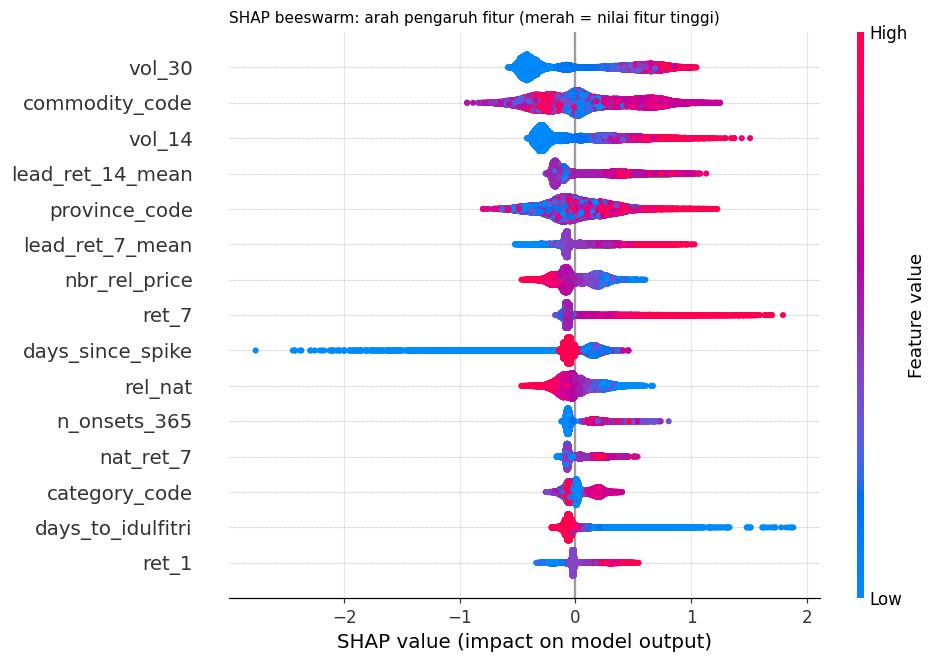

In [11]:
try:
    import shap
    plt.figure()
    shap.summary_plot(sv, Xs, max_display=15, show=False, plot_size=(9, 6))
    plt.title("SHAP beeswarm: arah pengaruh fitur (merah = nilai fitur tinggi)", loc="left", fontsize=10)
    plt.savefig(P.figures / "fig_06_06_shap_beeswarm.png", dpi=160, bbox_inches="tight"); plt.show()
except Exception as e:
    print("Plot beeswarm dilewati:", e)

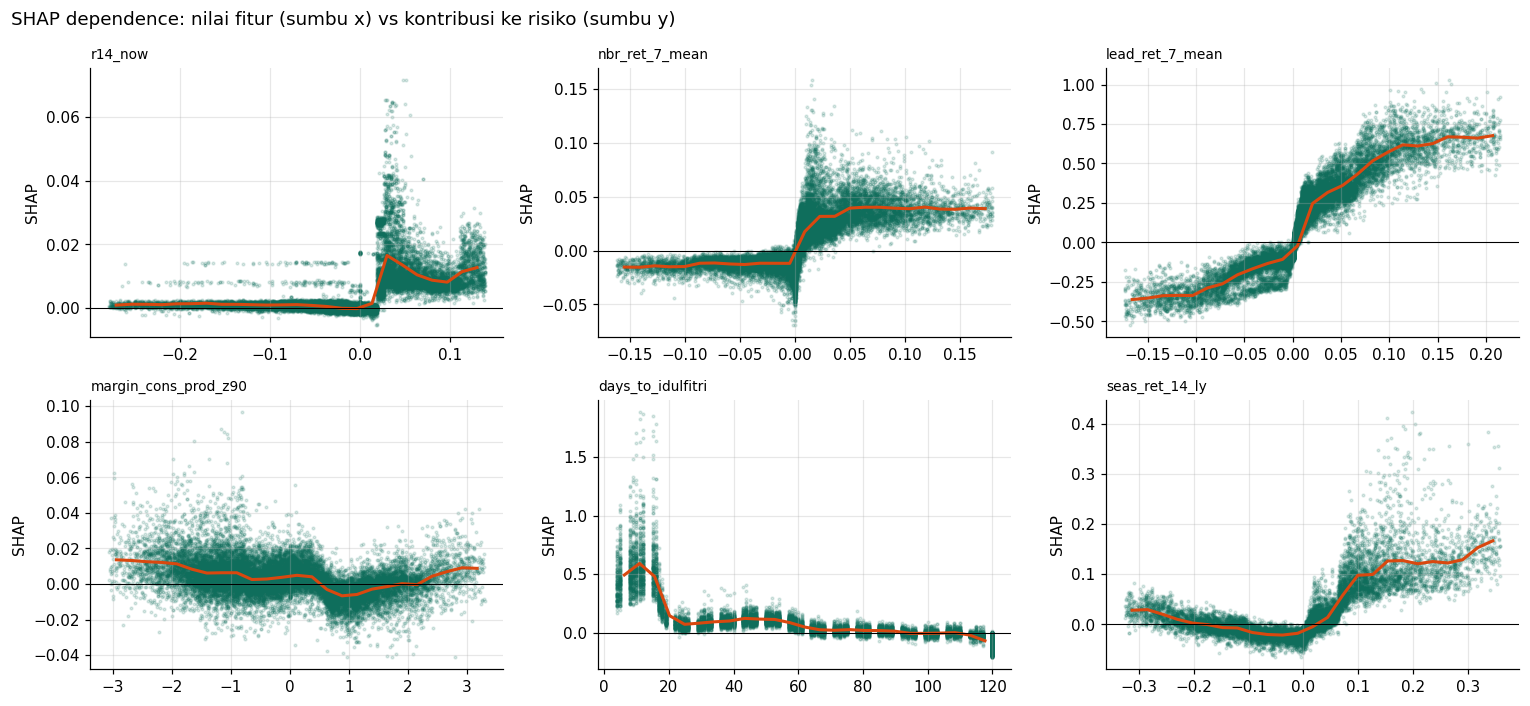

In [12]:
# Dependence: bagaimana nilai fitur kunci menggeser risiko
show = [f for f in ["r14_now", "nbr_ret_7_mean", "lead_ret_7_mean", "margin_cons_prod_z90", "days_to_idulfitri", "seas_ret_14_ly"] if f in fcols]
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, f in zip(axes.ravel(), show):
    j = fcols.index(f); x = Xs[f].to_numpy(); y_ = sv[:, j]
    ok = np.isfinite(x)
    lo, hi = np.nanpercentile(x[ok], [1, 99])
    m = ok & (x >= lo) & (x <= hi)
    ax.scatter(x[m], y_[m], s=3, alpha=.15, color=PALETTE["accent"])
    b = pd.Series(y_[m]).groupby(pd.cut(x[m], 25)).mean()
    ax.plot([i.mid for i in b.index], b.values, color=PALETTE["high"], lw=2)
    ax.axhline(0, color="k", lw=.7); ax.set_title(f, fontsize=9, loc="left"); ax.set_ylabel("SHAP")
fig.suptitle("SHAP dependence: nilai fitur (sumbu x) vs kontribusi ke risiko (sumbu y)", x=0.01, ha="left")
fig.tight_layout(); fig.savefig(P.figures / "fig_06_07_shap_dependence.png", dpi=160, bbox_inches="tight"); plt.show()

## 6.7 Studi kasus: satu kejadian lonjakan nyata
Dipilih otomatis: kejadian di periode penjelasan SHAP (out-of-sample) yang terdeteksi dengan lead time ≥ 7 hari dan kenaikan puncak terbesar untuk cabai/bawang.

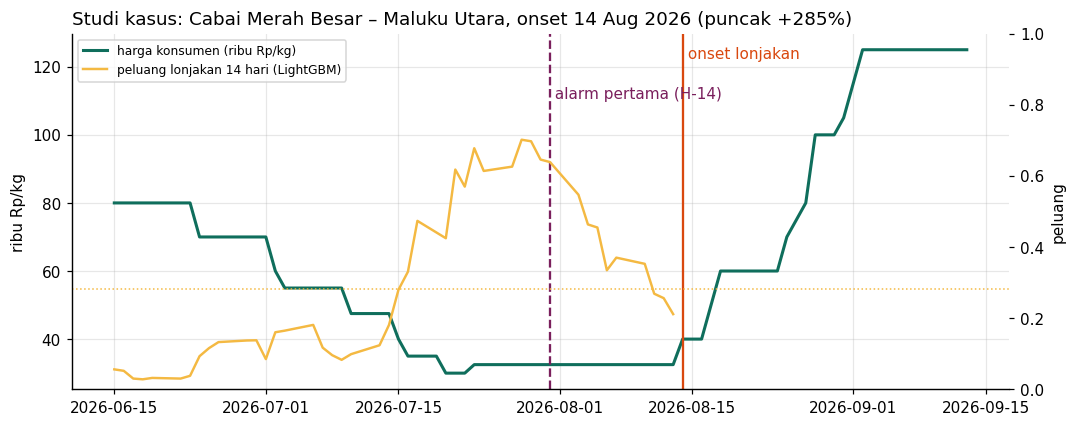

Pada alarm pertama (31 Jul 2026) peluang = 60%. Alasan utama (SHAP):
  + Harga sedang bergejolak: rata-rata ±6,2% per hari (30 hari terakhir)  (SHAP +0.72)
  + Provinsi "pemimpin" (biasanya naik duluan) berubah rata-rata +9,7% dalam 7 hari  (SHAP +0.46)
  + Harga 34,7% di bawah rata-rata nasional (berpotensi menyusul naik)  (SHAP +0.33)
  + Harga 27,8% lebih murah dari provinsi tetangga (berpotensi menyusul naik)  (SHAP +0.28)
  + Harga 67,5% di bawah puncak 90 hari terakhir  (SHAP +0.26)


In [13]:
cand = ed[(ed["date"] >= fx.test_start + pd.Timedelta(days=H)) & ed["detected"] & (ed["lead_days"] >= 7)
          & ed["commodity_id"].isin(["com_16", "com_14", "com_13", "com_15", "com_11"])]
cand = cand.sort_values("peak_rise_30d", ascending=False)
if len(cand):
    ev0 = cand.iloc[0]
    c, p, d = ev0["commodity_id"], int(ev0["province_id"]), ev0["date"]
    from radarpangan.pipeline import load_panel
    Pc = load_panel(P.processed / "panel_pt1.parquet")
    s = Pc[(c, p)].loc[d - pd.Timedelta(days=60): d + pd.Timedelta(days=30)]
    pr_ = pred[(pred["commodity_id"] == c) & (pred["province_id"] == p) & (pred["date"] >= s.index.min()) & (pred["date"] <= s.index.max())]
    thr_c = pr_["thr_lgbm"].median()
    first_alarm = pr_[(pr_["date"] >= d - pd.Timedelta(days=H)) & (pr_["date"] < d) & (pr_["score_lgbm"] >= pr_["thr_lgbm"])]["date"].min()
    fig, ax1 = plt.subplots(figsize=(11, 4.2))
    ax1.plot(s.index, s / 1000, color=PALETTE["accent"], lw=2, label="harga konsumen (ribu Rp/kg)")
    ax1.axvline(d, color=PALETTE["high"], lw=1.5); ax1.text(d, ax1.get_ylim()[1] * .97, " onset lonjakan", color=PALETTE["high"], va="top")
    ax1.axvline(first_alarm, color=PALETTE["spike"], lw=1.5, ls="--"); ax1.text(first_alarm, ax1.get_ylim()[1] * .88, f" alarm pertama (H-{(d - first_alarm).days})", color=PALETTE["spike"], va="top")
    ax1.set_ylabel("ribu Rp/kg")
    ax2 = ax1.twinx(); ax2.grid(False)
    ax2.plot(pr_["date"], pr_["score_lgbm"], color=PALETTE["watch"], lw=1.6, label="peluang lonjakan 14 hari (LightGBM)")
    ax2.axhline(thr_c, color=PALETTE["watch"], ls=":", lw=1); ax2.set_ylim(0, 1); ax2.set_ylabel("peluang")
    h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels(); ax1.legend(h1 + h2, l1 + l2, fontsize=8, loc="upper left")
    ax1.set_title(f"Studi kasus: {refs['com_name'][c]} – {refs['prov_name'][p]}, onset {d:%d %b %Y} (puncak +{ev0['peak_rise_30d']:.0%})", loc="left")
    fig.savefig(P.figures / "fig_06_08_studi_kasus.png", dpi=170, bbox_inches="tight"); plt.show()
    row = oos[(oos["commodity_id"] == c) & (oos["province_id"] == p) & (oos["date"] == first_alarm)]
    if len(row):
        sv1, _ = lgbm_shap(booster, row[fcols])
        prob1 = M.predict_lgbm(booster, row[fcols])[0]
        print(f"Pada alarm pertama ({first_alarm:%d %b %Y}) peluang = {prob1:.0%}. Alasan utama (SHAP):")
        for r in top_reasons(sv1[0], row.iloc[0], fcols, 5):
            print(f"  + {r['text']}  (SHAP {r['shap']:+.2f})")
else:
    print("Tidak ada kandidat studi kasus di periode ini.")

## 6.8 Validasi jaringan rambatan
Apakah edge yang dipelajari dari **2018–2021** masih berlaku di **2022–kini**? Diuji dengan *lift* presedensi kejadian pada periode uji: edge signifikan seharusnya punya lift lebih tinggi dibanding pasangan yang tidak signifikan.

In [14]:
from radarpangan.network import event_precedence
from radarpangan.labeling import make_labels, threshold_per_column
from radarpangan.pipeline import load_panel
Pc = load_panel(P.processed / "panel_pt1.parquet")
lab = make_labels(Pc, threshold_per_column(Pc.columns, refs["c2cat"], cfg), cfg)
e_train = pd.read_parquet(P.processed / "network_edges.parquet")
test_start = pd.Timestamp(cfg["validation"]["first_test_start"])
rows = []
for com_id in e_train["commodity_id"].unique():
    on = lab["onset"][com_id].loc[test_start:].drop(columns=[0], errors="ignore")
    if on.to_numpy().sum() < 20: continue
    ep_ = event_precedence(on, H)
    m_ = e_train[e_train["commodity_id"] == com_id][["source", "target", "significant"]].merge(ep_, on=["source", "target"])
    m_ = m_[np.isfinite(m_["lift"]) & (m_["n_onset_source"] >= 3)]
    rows.append({"komoditas": refs["com_name"][com_id],
                 "lift edge signifikan": m_.loc[m_["significant"], "lift"].mean(),
                 "lift pasangan lain": m_.loc[~m_["significant"], "lift"].mean(),
                 "n edge signifikan": int(m_["significant"].sum())})
nv_ = pd.DataFrame(rows).dropna()
nv_["rasio"] = nv_["lift edge signifikan"] / nv_["lift pasangan lain"]
display(nv_.sort_values("rasio", ascending=False).round(2).set_index("komoditas"))
print(f"Komoditas di mana edge 2018-2021 tetap lebih prediktif di 2022-kini: {(nv_['rasio'] > 1).sum()} dari {len(nv_)}")
nv_.to_csv(P.tables / "06_validasi_jaringan.csv", index=False)

,lift edge signifikan,lift pasangan lain,n edge signifikan,rasio
komoditas,,,,
Beras Kualitas Bawah II,12.2900,3.8300,9,3.2100
Daging Ayam Ras Segar,5.4300,1.8100,11,3.0000
Minyak Goreng Curah,14.3000,4.9300,33,2.9000
Daging Sapi Kualitas 2,7.4300,2.8400,18,2.6200
Daging Sapi Kualitas 1,10.2900,3.9700,3,2.5900
Beras Kualitas Medium I,9.7000,4.1700,7,2.3300
Beras Kualitas Medium II,6.8600,3.3700,9,2.0300
Bawang Putih Ukuran Sedang,13.0800,6.7400,88,1.9400
Cabai Rawit Merah,2.3500,1.2500,119,1.8800


Komoditas di mana edge 2018-2021 tetap lebih prediktif di 2022-kini: 13 dari 21


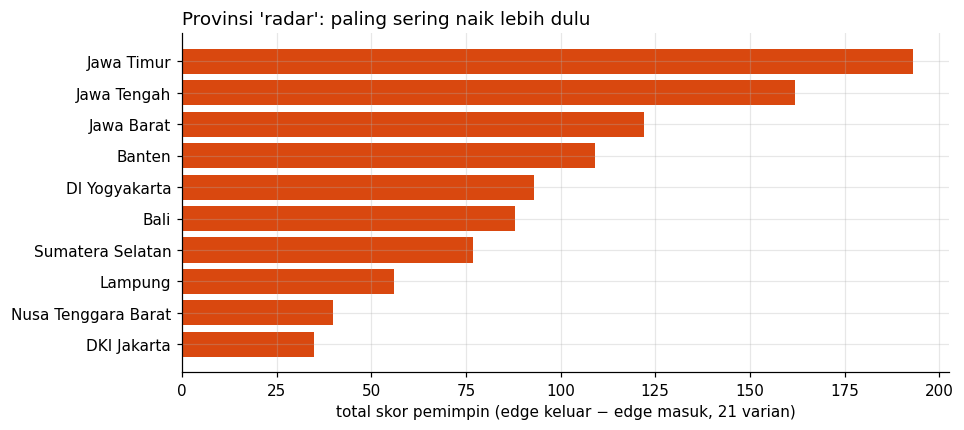

,skor pemimpin total
province_id,
Jawa Timur,193
Jawa Tengah,162
Jawa Barat,122
Banten,109
DI Yogyakarta,93
Bali,88
Sumatera Selatan,77
Lampung,56
Nusa Tenggara Barat,40


In [15]:
# Provinsi "radar": paling sering jadi pemimpin di semua komoditas (jaringan final)
ls_full = pd.read_parquet(P.processed / "leader_scores_final.parquet")
agg = ls_full.groupby("province_id")["leader_score"].sum().sort_values(ascending=False)
agg.index = agg.index.map(refs["prov_name"])
fig, ax = plt.subplots(figsize=(9, 4))
top10 = agg.head(10)[::-1]
ax.barh(top10.index, top10.values, color=PALETTE["high"])
ax.set_xlabel("total skor pemimpin (edge keluar − edge masuk, 21 varian)")
ax.set_title("Provinsi 'radar': paling sering naik lebih dulu", loc="left")
fig.savefig(P.figures / "fig_06_09_provinsi_radar.png", dpi=170, bbox_inches="tight"); plt.show()
display(agg.head(10).rename("skor pemimpin total").to_frame())

## 6.9 Cek kriteria sukses (ditetapkan di notebook 01)

In [16]:
t = table.set_index("key")
ok_all = all(t.at["lgbm", "pr_auc"] > t.at[m, "pr_auc"] for m in ["naive", "seasonal", "logreg"])
if sar_path.exists():
    ts = tab_s.set_index("key"); ok_all = ok_all and ts.at["lgbm", "pr_auc"] > ts.at["sarima", "pr_auc"]
crit = pd.DataFrame([
    {"kriteria": "PR-AUC LightGBM ≥ 1,5× naive", "target": "≥ 1,5×", "hasil": f"{t.at['lgbm', 'pr_auc'] / t.at['naive', 'pr_auc']:.2f}×",
     "status": t.at["lgbm", "pr_auc"] / t.at["naive", "pr_auc"] >= 1.5},
    {"kriteria": "LightGBM > semua baseline (termasuk SARIMA di subset)", "target": "ya", "hasil": "ya" if ok_all else "tidak", "status": ok_all},
    {"kriteria": "Deteksi kejadian", "target": "≥ 60%", "hasil": f"{t.at['lgbm', 'event_detection_rate']:.0%}", "status": t.at["lgbm", "event_detection_rate"] >= 0.6},
    {"kriteria": "Median lead time", "target": "≥ 7 hari", "hasil": f"{t.at['lgbm', 'median_lead_days']:.0f} hari", "status": t.at["lgbm", "median_lead_days"] >= 7},
    {"kriteria": "FAR & episode alarm palsu dilaporkan + dapat diatur", "target": "ya",
     "hasil": f"FAR {t.at['lgbm', 'far']:.0%}; {t.at['lgbm', 'false_episodes_per_series_year']:.2f} episode palsu/seri/thn", "status": True},
    {"kriteria": "Validasi tanpa kebocoran", "target": "ya", "hasil": "walk-forward + purge 14 hr + uji leakage (NB04) lulus", "status": True},
])
crit["status"] = crit["status"].map({True: "✅ tercapai", False: "❌ belum"})
display(crit.style.hide(axis="index"))
crit.to_csv(P.tables / "06_kriteria_sukses.csv", index=False)

kriteria,target,hasil,status
"PR-AUC LightGBM ≥ 1,5× naive","≥ 1,5×",1.96×,✅ tercapai
LightGBM > semua baseline (termasuk SARIMA di subset),ya,ya,✅ tercapai
Deteksi kejadian,≥ 60%,85%,✅ tercapai
Median lead time,≥ 7 hari,11 hari,✅ tercapai
FAR & episode alarm palsu dilaporkan + dapat diatur,ya,FAR 55%; 1.30 episode palsu/seri/thn,✅ tercapai
Validasi tanpa kebocoran,ya,walk-forward + purge 14 hr + uji leakage (NB04) lulus,✅ tercapai


## 6.10 Tinjauan proses & langkah berikutnya

**Pengaman kualitas yang sudah diterapkan**
- Validasi *walk-forward* (19 fold, ± 4,7 tahun uji) + *purge* 14 hari; ambang & early stopping hanya dari data validasi.
- Uji leakage fitur (NB04) lulus; klimatologi hujan dari 1991–2017; provinsi pemimpin untuk evaluasi dipelajari dari data ≤ 2021.
- Tuning hyperparameter hanya memakai periode sebelum 2022.
- Implementasi Granger diverifikasi terhadap statsmodels; SARIMA diuji bebas kebocoran.

**Keterbatasan**
- Harga PIHPS adalah rata-rata provinsi; lonjakan lokal (kab/kota) bisa tersamarkan.
- Harga beras/gula/minyak/daging sapi sering "lengket" (jarang diperbarui) → kejadian lebih sedikit, evaluasi per kategori lebih bervariasi.
- Tidak ada data stok/produksi/distribusi harian publik; sinyal pasokan hanya didekati.
- Granger menunjukkan **keterdahuluan statistik**, bukan bukti hubungan sebab-akibat fisik (arus barang).
- Sinyal margin produsen–konsumen tidak meningkatkan performa (ablation 6.5): fitur ini bisa dihapus untuk menyederhanakan model, atau diganti data rantai pasok yang lebih lengkap (stok, distribusi, impor).
- Ambang alarm dipilih untuk F1; pengguna dengan toleransi alarm palsu berbeda dapat memakai kurva trade-off (6.3).
- Pada kategori dengan kejadian sangat jarang (proporsi positif < 1%, mis. telur & gula), keunggulan LightGBM atas baseline sederhana **tidak konsisten** (tabel 6.2) → kandidat perbaikan: ambang/model khusus kategori atau data tambahan (stok, impor, HET).
- FAR harian masih tinggi (sekitar separuh hari beralarm tidak diikuti lonjakan). Ini wajar untuk kejadian langka, tetapi perlu dikomunikasikan sebagai "peringatan untuk waspada", bukan kepastian.

**Keputusan**: kriteria sukses dicek di tabel 6.9 → lanjut ke **Deployment** (model final + dashboard publik + pembaruan harian + monitoring).
Ide pengembangan: fitur harga tingkat kab/kota, data impor/stok Bulog, model *survival*/hazard untuk waktu-sampai-lonjakan, kalibrasi probabilitas (isotonic), dan umpan balik pengguna TPID.

➡️ Lanjut ke **`07_deployment.ipynb`**.